In [8]:
# auto reload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import cns.data_utils as cdu
import cns
import numpy as np
from scipy.stats import mannwhitneyu
import pandas as pd
from statsmodels.stats.multitest import multipletests

plt.rcParams.update({'font.size': 12})
color_map = plt.cm.get_cmap('tab10').colors[:10]

C:\Users\adams\AppData\Local\Temp\ipykernel_44992\3869226692.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab10').colors[:10]


In [10]:
samples_df, cns_df = cdu.main_load("2MB")
cns_df = cns.only_aut(cns.add_total_cn(cns_df))
datasets = samples_df["source"].unique()

In [11]:
lusc_sel = cns.select_cns_by_type(cns_df, samples_df, "LUSC")
lusc_var = cns.calc_chrom_var(lusc_sel, "total_cn")
luad_sel = cns.select_cns_by_type(cns_df, samples_df, "LUAD")
luad_var = cns.calc_chrom_var(luad_sel, "total_cn").sort_values(ascending=False)

In [12]:
# Merge luad_var and lusc_var into a single DataFrame for comparison
var_df = pd.DataFrame({
    'LUAD_var': luad_var,
    'LUSC_var': lusc_var
})
var_df["merge_var"] = (var_df["LUAD_var"] + var_df["LUSC_var"]) / 2
var_df.sort_values("merge_var", ascending=False, inplace=True)
var_df

,LUAD_var,LUSC_var,merge_var
chrom,,,
chr3,1.596149,7.671888,4.634018
chr8,5.828479,3.430185,4.629332
chr5,3.141258,3.783358,3.462308
chr7,3.950940,2.740429,3.345685
chr20,2.869458,2.973764,2.921611
chr19,2.721068,2.785295,2.753181
chr14,3.166033,2.174225,2.670129
chr12,3.155376,2.039519,2.597448
chr11,1.634091,2.897709,2.265900


In [13]:
print("Mean var", var_df.mean())

Mean var LUAD_var     2.230324
LUSC_var     2.466623
merge_var    2.348473
dtype: float64


(<Figure size 1440.52x400 with 1 Axes>,
 <Axes: xlabel='position on the linear genome', ylabel='total_cn'>)

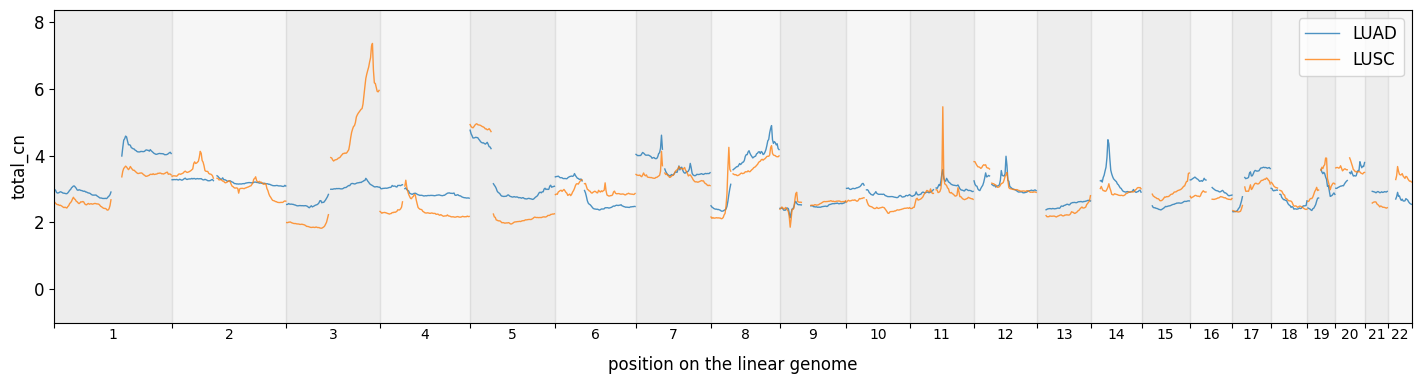

In [14]:
lusc_all = cns.group_samples(lusc_sel, group_name="LUSC")
luad_all = cns.group_samples(luad_sel, group_name="LUAD")
both_all = pd.concat([lusc_all, luad_all], axis=0)
cns.fig_lines(both_all, "total_cn", colors=color_map[:2])

In [15]:
wd_all = cns.calc_chrom_distances(both_all, "total_cn")
wd_all.sort_values(ascending=False)

chr3     0.335958
chr5     0.189489
chr6     0.127250
chr14    0.085600
chr20    0.076484
chr4     0.068829
chr2     0.067103
chr7     0.065015
chr12    0.064854
chr8     0.049430
chr11    0.045426
chr16    0.043527
chr19    0.038746
chr17    0.028128
chr15    0.027945
chr13    0.026687
chr1     0.025134
chr18    0.023012
chr21    0.022880
chr9     0.021490
chr10    0.015018
chr22    0.012550
dtype: float64

In [16]:
def first_name(name):
    return name.split("_")[0]

In [17]:
datasets = ["PCAWG", "TRACERx", "TCGA_hg19"]
luad_dict = { f'{first_name(k)} LUAD': cns.select_cns_by_type(cns_df, samples_df.query(f"source == '{k}'"), "LUAD") for k in datasets }
lusc_dict = { f'{first_name(k)} LUSC': cns.select_cns_by_type(cns_df, samples_df.query(f"source == '{k}'"), "LUSC") for k in datasets }
all_dict = luad_dict | lusc_dict
means_single = pd.concat([cns.add_total_cn(cns.group_samples(v, group_name=k)) for k, v in all_dict.items()])

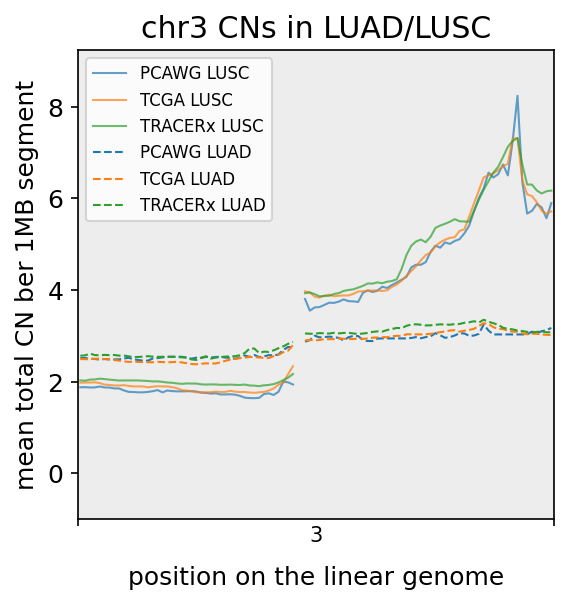

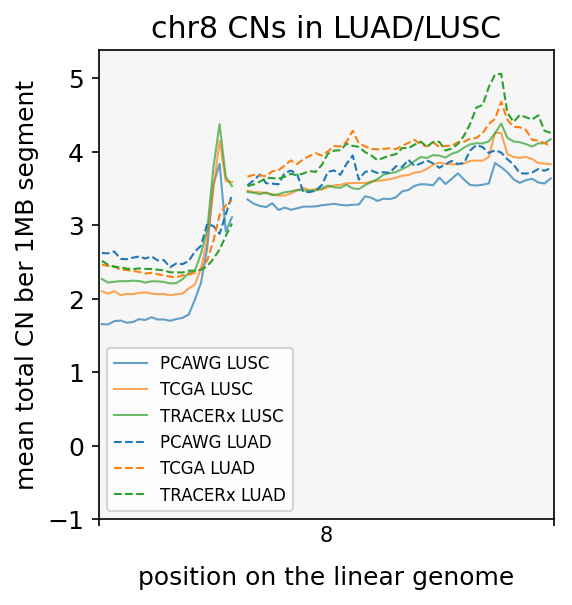

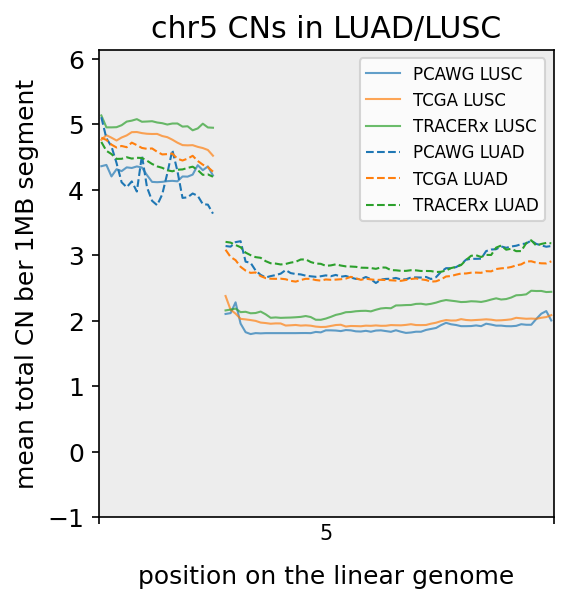

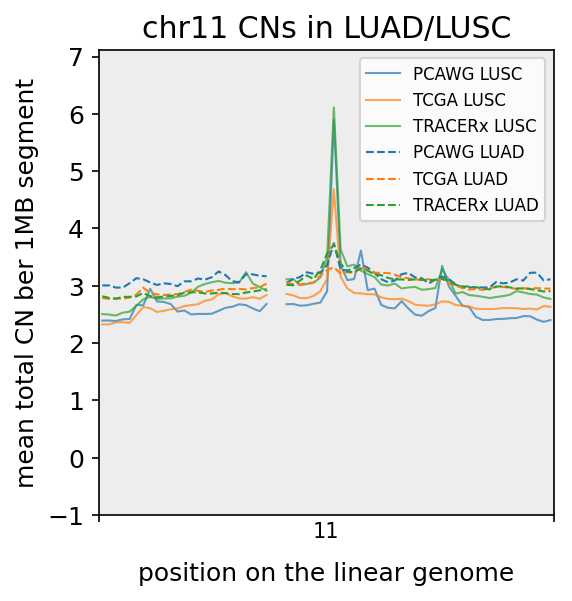

In [18]:
chroms = ["chr3", "chr8", "chr5", "chr11"]
for chrom in chroms:
	lusc_means = means_single.query(f"chrom == '{chrom}' and sample_id.str.endswith('LUSC')", engine='python')
	fig, ax = cns.fig_lines(lusc_means, cn_columns="total_cn", colors=color_map[:3])
	lines = list(ax.lines)

	luad_means = means_single.query(f"chrom == '{chrom}' and sample_id.str.endswith('LUAD')", engine='python')
	for i, (name, group) in enumerate(luad_means.groupby("sample_id")):
		cns.plot_lines(ax, group, cn_column="total_cn", color=color_map[i], label=name)

	for line in ax.lines:
		line.set_linestyle("--")
	for line in lines:
		line.set_linestyle("-")

	ax.set_ylabel("mean total CN ber 1MB segment")
	ax.set_title(f"{chrom} CNs in LUAD/LUSC")
	ax.legend(fontsize=8)
	fig.set_dpi(150)
	cdu.save_cns_fig(f"fig_LUAD_LUSC_single_{chrom}")

In [19]:
# pearson correlation of means_single[0]["total_cn"] and means_single[1]["total_cn"]
datasets = ["PCAWG", "TRACERx", "TCGA"]
print("Correlations on 1 Mb segments between datasets")
correlations = []
for ctype in ["LUAD", "LUSC"]:
    for i in datasets:
        for j in datasets:
            if i == j:
                continue
            first = f"{i} {ctype}"
            second = f"{j} {ctype}"
            pair = pd.concat([means_single.query(f"sample_id == '{i} {ctype}'"), means_single.query(f"sample_id == '{j} {ctype}'")])
            dist_val = cns.calc_chrom_distances(pair, "total_cn")['chr3']
            correlations.append((i, j, ctype, dist_val))

corr_df = pd.DataFrame(correlations, columns=["first", "second", "type", "dist"])
print("Mean LUAD: ", corr_df.query("type == 'LUAD'")["dist"].mean())
print("Mean LUSC: ", corr_df.query("type == 'LUSC'")["dist"].mean())

Correlations on 1 Mb segments between datasets
Mean LUAD:  0.020153684561892055
Mean LUSC:  0.03172110581281741


In [20]:
# pearson correlation of means_single[0]["total_cn"] and means_single[1]["total_cn"]
datasets = ["PCAWG", "TRACERx", "TCGA"]
print("Correlations on 1 Mb segments between datasets")
correlations = []
for i in datasets:
    for j in datasets:
        if i != j:
            continue
        first = f"{i} {ctype}"
        second = f"{j} {ctype}"
        pair = pd.concat([means_single.query(f"sample_id == '{i} LUSC'"), means_single.query(f"sample_id == '{j} LUAD'")])
        dist_val = cns.calc_chrom_distances(pair, "total_cn")['chr3']
        correlations.append((i, j, "LUSC", "LUAD", dist_val))

corr_df = pd.DataFrame(correlations, columns=["first", "second", "type 1", "type 2", "dist"])
print("Mean distances between LUAD and LUSC: ", corr_df["dist"].mean())

Correlations on 1 Mb segments between datasets
Mean distances between LUAD and LUSC:  0.34633282485533917


In [21]:
_, cosmic_df = cdu.main_load("COSMIC")
cosmic_group = cns.group_samples(cosmic_df)

In [22]:
cosmic_lusc_ind_df = cns.select_cns_by_type(cosmic_df, samples_df, "LUSC")
cosmic_lusc_group = cns.add_total_cn(cns.group_samples(cosmic_lusc_ind_df, group_name="COSMIC LUSC"))
cosmic_luad_ind_df = cns.select_cns_by_type(cosmic_df, samples_df, "LUAD")
cosmic_luad_group = cns.add_total_cn(cns.group_samples(cosmic_luad_ind_df, group_name="COSMIC LUAD"))
cosmic_both = pd.concat([cosmic_lusc_group, cosmic_luad_group])

In [23]:
# Plot the top attributions
cosmic_lusc_group.sort_values("total_cn", ascending=False).head()

,chrom,start,end,name,major_cn,minor_cn,sample_id,total_cn
482,chr3,181429713,181432221,SOX2,5.761044,1.800201,COSMIC LUSC,7.561245
481,chr3,178865901,178957881,PIK3CA,5.136358,1.793944,COSMIC LUSC,6.930302
480,chr3,176737142,176915261,TBL1XR1,4.979333,1.795855,COSMIC LUSC,6.775188
483,chr3,185000728,185206885,MAP3K13,4.852308,1.730944,COSMIC LUSC,6.583252
484,chr3,185361526,185542844,IGF2BP2,4.738830,1.718823,COSMIC LUSC,6.457654


In [24]:
# Plot the neighbours of SOX2
cosmic_lusc_group.query("chrom == 'chr3'").query("start > 175000000").head()

,chrom,start,end,name,major_cn,minor_cn,sample_id,total_cn
480,chr3,176737142,176915261,TBL1XR1,4.979333,1.795855,COSMIC LUSC,6.775188
481,chr3,178865901,178957881,PIK3CA,5.136358,1.793944,COSMIC LUSC,6.930302
482,chr3,181429713,181432221,SOX2,5.761044,1.800201,COSMIC LUSC,7.561245
483,chr3,185000728,185206885,MAP3K13,4.852308,1.730944,COSMIC LUSC,6.583252
484,chr3,185361526,185542844,IGF2BP2,4.738830,1.718823,COSMIC LUSC,6.457654


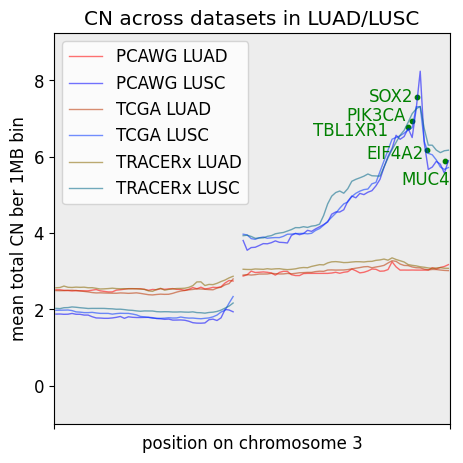

In [25]:
from cns import hg19
colors = ["#FF0000", "#0000FF", "#BB3300", "#0033FF", "#886600", "#006688"]
fig, ax = cns.fig_lines(means_single.query("chrom == 'chr3'"), cn_columns="total_cn", colors=colors)
ax.set_ylabel("mean total CN ber 1MB bin")
ax.set_title("CN across datasets in LUAD/LUSC")
ax.legend(loc='upper left')
fig.set_size_inches(5, 5) 
# erase x labels

offsets = {
    'EIF4A2': (-.2, -.1),
    'SOX2': (-.2, 0),
    'TBL1XR1': (-1, -.1),
    'PIK3CA': (-.3, .15),
    "MUC4": (.25, -.5)
}

for i, row in cosmic_lusc_group.iterrows():
    if row['name'] in ['EIF4A2', 'SOX2', 'TBL1XR1', 'PIK3CA', "MUC4"]:
        mid = cns.calc_mid(row) + hg19.chr_starts["chr3"]
        plt.scatter(mid, row['total_cn'], color='green', s=10)
        name = row['name']
        x, y = offsets[name]
        plt.text(mid + x*10**7, row['total_cn'] + y, name, color="green", size=12, ha='right', va='center')

ax.set_xticklabels([], minor=True)
ax.set_xlabel("position on chromosome 3", labelpad=-12)

cdu.save_cns_fig(f"fig_COSMIC_lines_IG_att_chr3")

Mean LUSC CN: 5.640136705763451


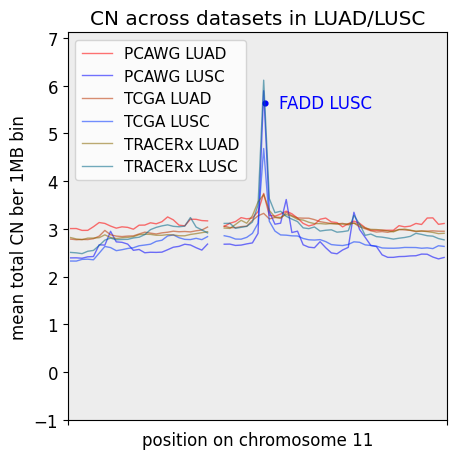

In [26]:
from cns import hg19
colors = ["#FF0000", "#0000FF", "#BB3300", "#0033FF", "#886600", "#006688"]
fig, ax = cns.fig_lines(means_single.query("chrom == 'chr11'"), cn_columns="total_cn", colors=colors)
ax.set_ylabel("mean total CN ber 1MB bin")
ax.set_title("CN across datasets in LUAD/LUSC")
ax.legend(loc='upper left', fontsize=11)
fig.set_size_inches(5, 5) 
# erase x labels

offsets = {
    "FADD": (.5, 0)
}

for i, row in cosmic_lusc_group.iterrows():
    if row['name'] in ['FADD']:
        mid = cns.calc_mid(row) + hg19.chr_starts["chr11"]
        plt.scatter(mid, row['total_cn'], color='blue', s=12)
        name = row['name']
        x, y = offsets[name]
        plt.text(mid + x*10**7, row['total_cn'] + y, name + " LUSC", color="blue", size=12, ha='left', va='center')
        print("Mean LUSC CN:", row['total_cn'],)

ax.set_xticklabels([], minor=True)
ax.set_xlabel("position on chromosome 11", labelpad=-12)

cdu.save_cns_fig(f"fig_COSMIC_lines_IG_att_chr11")

In [37]:
for type_df in [cosmic_luad_ind_df, cosmic_lusc_ind_df]:
	type_df["alt"] = (type_df["major_cn"] + type_df["minor_cn"] - 2).astype(int)
print(cosmic_luad_ind_df.head())

           sample_id chrom    start      end  major_cn  minor_cn      name  \
0  CRUK0001_SU_T1-R1  chr1  2160133  2241558       2.0       2.0       SKI   
1  CRUK0001_SU_T1-R1  chr1  2487077  2496821       2.0       2.0  TNFRSF14   
2  CRUK0001_SU_T1-R1  chr1  2985731  3355185       2.0       2.0    PRDM16   
3  CRUK0001_SU_T1-R1  chr1  6241328  6269449       2.0       2.0     RPL22   
4  CRUK0001_SU_T1-R1  chr1  6845383  7829766       2.0       2.0    CAMTA1   

   alt  
0    2  
1    2  
2    2  
3    2  
4    2  


In [54]:
cruk_1_samples = luad_dict["TRACERx LUAD"].query("sample_id.str.startswith('CRUK0001')")

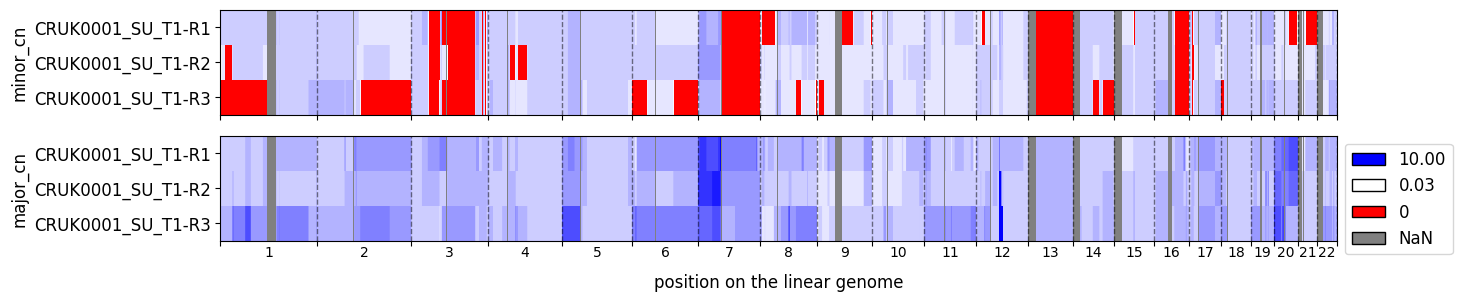

In [60]:
cns.fig_heatmap(cruk_1_samples, cn_columns=["minor_cn", "major_cn"])

cdu.save_cns_fig("fig_CRUK0001_heatmap")

In [ ]:
new_tree = "((CRUK0001_SU_T1-R3:91.00000,(CRUK0001_SU_T1-R1:95.00000,CRUK0001_SU_T1-R2:52.00000)internal1:29.00000)internal2:82.00000,diploid:0.00000):0.00000;"



In [ ]:

def test_gene_alterations(luad_df, lusc_df, alpha=0.05):   
    results = []
    
    for gene in luad_df['name'].unique():
        # Get alteration values for this gene in both types
        luad_alt = luad_df[luad_df['name'] == gene]['alt'].values
        lusc_alt = lusc_df[lusc_df['name'] == gene]['alt'].values

        # Perform Wilcoxon rank-sum test
        statistic, p_value = mannwhitneyu(luad_alt, lusc_alt, alternative='two-sided')
        
        # Calculate effect size (median difference)
        median_luad = np.median(luad_alt)
        median_lusc = np.median(lusc_alt)
        effect_size = median_luad - median_lusc
        
        # Calculate means for additional info
        mean_luad = np.mean(luad_alt)
        mean_lusc = np.mean(lusc_alt)
        
        results.append({
            'gene': gene,
            'p_value': p_value,
            'statistic': statistic,
            'median_luad': median_luad,
            'median_lusc': median_lusc,
            'mean_luad': mean_luad,
            'mean_lusc': mean_lusc,
            'effect_size': effect_size,
            'n_luad': len(luad_alt),
            'n_lusc': len(lusc_alt)
        })

    
    results_df = pd.DataFrame(results)

    # Apply multiple testing correction (Benjamini-Hochberg)    
    rejected, p_adjusted, alpha_sidak, alpha_bonf = multipletests(
        results_df['p_value'], alpha=alpha, method='fdr_bh'
    )
    
    results_df['p_adjusted'] = p_adjusted
    results_df['significant'] = rejected
    
    
    return  results_df.sort_values('p_value')


# Perform the statistical test
gene_test_results = test_gene_alterations(cosmic_luad_ind_df, cosmic_lusc_ind_df)

print(f"\nStatistical Test Results:")
print(f"Total genes tested: {len(gene_test_results)}")
print(f"Significant genes (p < 0.05): {gene_test_results['significant'].sum()}")
print(f"Significant genes (p_adjusted < 0.05): {(gene_test_results['p_adjusted'] < 0.05).sum()}")

# Display top 10 most significant genes
print("\nTop 10 most significant genes:")
top_genes = gene_test_results.head(10)
print(top_genes[['gene', 'p_value', 'p_adjusted', 'effect_size', 'median_luad', 'median_lusc', 'significant']])

Found 722 common genes between LUAD and LUSC

Statistical Test Results:
Total genes tested: 722
Significant genes (p < 0.05): 599
Significant genes (p_adjusted < 0.05): 599

Top 10 most significant genes:
        gene        p_value     p_adjusted  effect_size  median_luad  \
300     SOX2  2.061424e-190  1.488348e-187         -3.0          1.0   
712   PIK3CA  1.053644e-181  3.803656e-179         -3.0          1.0   
468  MAP3K13  1.299813e-174  3.128217e-172         -3.0          1.0   
274  TBL1XR1  1.223585e-172  2.029722e-170         -3.0          1.0   
539  IGF2BP2  1.405625e-172  2.029722e-170         -3.0          1.0   
159     TP63  2.432792e-168  2.927460e-166         -3.0          1.0   
503     ETV5  4.750184e-168  4.899476e-166         -3.0          1.0   
80       LPP  6.536332e-167  5.899040e-165         -3.0          1.0   
287     BCL6  8.156288e-167  6.543155e-165         -3.0          1.0   
691   EIF4A2  6.821438e-166  4.925078e-164         -3.0          1.0   

  